# Hexbin plotting for Simulation Experiments

In [1]:
%cd ../..

/home/bhkuser/bhklab/katy/recist-vs-reality


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

from damply import dirs
from pathlib import Path

In [ ]:
dataset = "CVPR_LesionLocator"

fig_save_path = Path("figures") / dataset
fig_save_path.mkdir(parents=True, exist_ok=True)

In [3]:
def get_source_dataset(source_id:str) -> str:
    # Get dataset name based on source_id value (e.g.KiTS23_case_00001)
    if "KiTS" in source_id: 
        dataset = "KiTS"
    elif "LIDC-IDRI" in source_id: 
        dataset = "LIDC-IDRI"
    elif "LNDb" in source_id: 
        dataset = "LNDb" 
    elif "MSD_colon" in source_id: 
        dataset = "MSD Colon"
    elif "MSD_hepaticvessel" in source_id: 
        dataset = "MSD Hepatic\nVessel" 
    elif "MSD_liver" in source_id: 
        dataset = "MSD Liver" 
    elif "MSD_lung" in source_id: 
        dataset = "MSD Lung"
    elif "MSD_pancreas" in source_id: 
        dataset = "MSD Pancreas"
    elif "NSCLC-Radiogenomics" in source_id: 
        dataset = "NSCLC-\nRadiogenomics" 
    else: 
        dataset = 'unknown'
    return dataset

In [4]:
def add_source_labels(main_df, mapping_df):
    # Merge this name mapping into the main dataframe for med
    main_lbl_df = main_df.merge(mapping_df, left_on="sample_id", right_on="File Name", how="left")
    # Drop duplicate column File Name, is same as sample_id
    main_lbl_df = main_lbl_df.drop(labels="File Name", axis=1)
    # Rename Source column to source_id for continuity with sample_id
    main_lbl_df = main_lbl_df.rename(columns={'Source': "source_id"})

    # Add source_dataset column to main dataframe based on source_id
    main_lbl_df['source_dataset'] = main_lbl_df["source_id"].apply(get_source_dataset)

    return main_lbl_df

In [5]:
# Load in aligned simulation data 
# MedSAM2-RECIST = ms2r
ms2r_recist_path = dirs.RESULTS / "CCS_LL" / "ms2r_ll_sim_plotting_info.csv"
# nnInteractive = nnint
nnint_recist_path = dirs.RESULTS / "CCS_LL" / "nnint_ll_sim_plotting_info.csv"

ms2r_recist_df = pd.read_csv(ms2r_recist_path) 
nnint_recist_df = pd.read_csv(nnint_recist_path) 

In [6]:
# Get the stem of the parent directory for each image in the GT_t1_mask_path column
def get_sample_id(path):
    return Path(path).parent.stem

ms2r_recist_df['sample_id'] = ms2r_recist_df['GT_t1_mask_path'].apply(get_sample_id)
nnint_recist_df['sample_id'] = nnint_recist_df['GT_t1_mask_path'].apply(get_sample_id)

In [7]:
# Load in name mapping for the LesionLocator data to the included datasets
name_mapping_path = dirs.RAWDATA / "CVPR_LesionLocator/images/naming.csv"
name_mapping_df = pd.read_csv(name_mapping_path)

ms2r_recist_lbl_df = add_source_labels(ms2r_recist_df, name_mapping_df)
nnint_recist_lbl_df = add_source_labels(nnint_recist_df, name_mapping_df)

# 3D DICE

Have to make count hexbin figure first to get the number of values in each bin. The array from this plot is then used to set the alpha in the flip plot below.

## Count Plot

Text(0.5, 0.98, '3D DICE Score vs. Number of Samples in Bin')

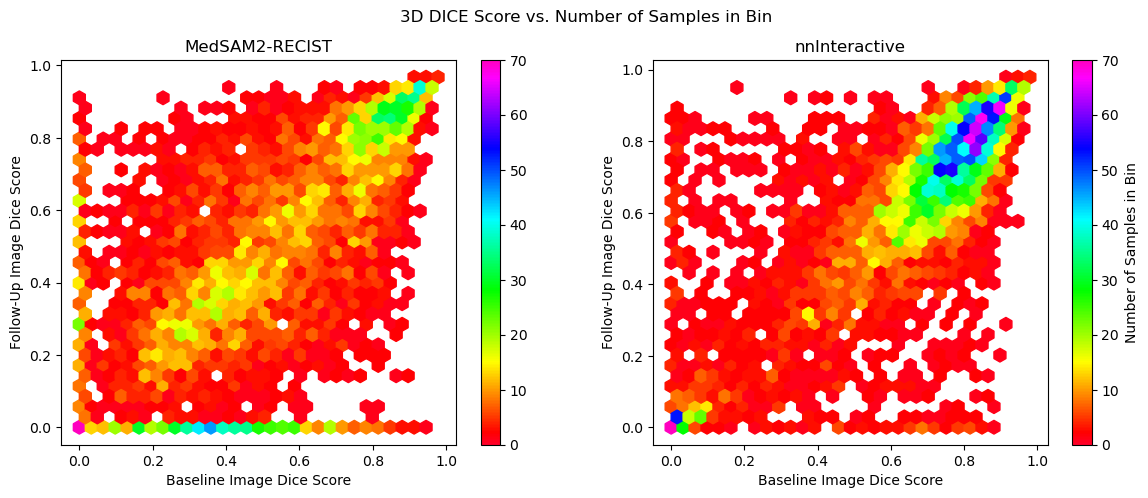

In [8]:
count_fig, count_axes = plt.subplots(figsize = (14,5), nrows = 1, ncols = 2)

count_gridsize = 30
count_cmap = 'gist_rainbow'
count_vmin = 0
count_vmax = 70

# For MedSAM2-RECIST 
ms2r_count = count_axes[0].hexbin(ms2r_recist_df['t1_DICE'], ms2r_recist_df['t2_DICE'],
                               gridsize = count_gridsize,
                               cmap = count_cmap,
                               mincnt = 1,
                               vmin = count_vmin,
                               vmax = count_vmax,
                               )
count_axes[0].set_title("MedSAM2-RECIST")
count_axes[0].set_xlabel("Baseline Image Dice Score") 
count_axes[0].set_ylabel("Follow-Up Image Dice Score")
cb = count_fig.colorbar(ms2r_count, ax = count_axes[0])

# For nnInteractive
nnint_count = count_axes[1].hexbin(nnint_recist_df['t1_DICE'], nnint_recist_df['t2_DICE'],
                                gridsize = count_gridsize,
                                cmap = count_cmap,
                                mincnt = 1,
                                vmin = count_vmin,
                                vmax = count_vmax,
                            )
count_axes[1].set_title("nnInteractive")
count_axes[1].set_xlabel("Baseline Image Dice Score") 
count_axes[1].set_ylabel("Follow-Up Image Dice Score")
cb = count_fig.colorbar(nnint_count, ax = count_axes[1])

cb.set_label("Number of Samples in Bin") 

count_fig.suptitle("3D DICE Score vs. Number of Samples in Bin")

## Flip Plot

Text(0.5, 0.98, '3D DICE Score vs. RECIST Flip Proportion')

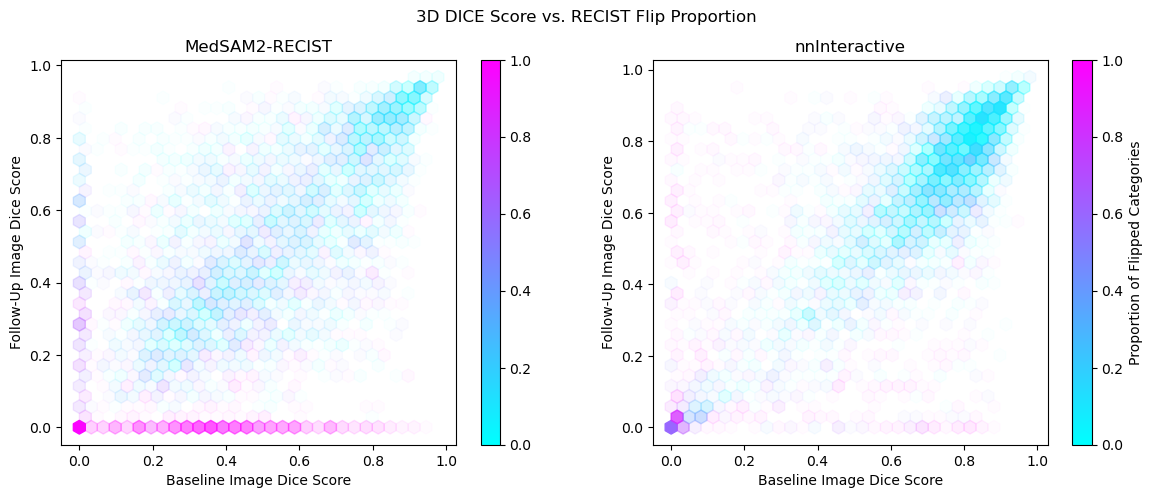

In [9]:
alpha_flip_fig, alpha_flip_axes = plt.subplots(figsize = (14,5), nrows = 1, ncols = 2)
# For MedSAM2-RECIST 
ms2r_hb = alpha_flip_axes[0].hexbin(ms2r_recist_df['t1_DICE'], ms2r_recist_df['t2_DICE'], C=ms2r_recist_df['RECIST_flip'], 
                         reduce_C_function=np.mean, gridsize = 30, cmap = 'cool')

alpha_flip_axes[0].figure.canvas.draw()

fcolors = ms2r_hb.get_facecolors()
scaled_ms2r_count = np.minimum(ms2r_count.get_array() / count_vmax, 1)
fcolors[:, 3] = scaled_ms2r_count
ms2r_hb.set(array=None, facecolor=fcolors)

alpha_flip_axes[0].set_title("MedSAM2-RECIST")
alpha_flip_axes[0].set_xlabel("Baseline Image Dice Score") 
alpha_flip_axes[0].set_ylabel("Follow-Up Image Dice Score")
cb = alpha_flip_fig.colorbar(ms2r_hb, ax = alpha_flip_axes[0])

# For nnInteractive
nnint_hb = alpha_flip_axes[1].hexbin(nnint_recist_df['t1_DICE'], nnint_recist_df['t2_DICE'], C=nnint_recist_df['RECIST_flip'], 
                         reduce_C_function=np.mean, gridsize=30, cmap='cool')

alpha_flip_axes[1].figure.canvas.draw()

fcolors = nnint_hb.get_facecolors()
scaled_nnint_count = np.minimum(nnint_count.get_array() / count_vmax, 1)
fcolors[:, 3] = scaled_nnint_count
nnint_hb.set(array=None, facecolor=fcolors)

alpha_flip_axes[1].set_title("nnInteractive")
alpha_flip_axes[1].set_xlabel("Baseline Image Dice Score") 
alpha_flip_axes[1].set_ylabel("Follow-Up Image Dice Score")
cb = alpha_flip_fig.colorbar(nnint_hb, ax = alpha_flip_axes[1])
cb.set_label("Proportion of Flipped Categories") 

alpha_flip_fig.suptitle("3D DICE Score vs. RECIST Flip Proportion")

# 2D DICE

## Count Plot

Text(0.5, 0.98, '2D DICE Score vs. Number of Samples in Bin')

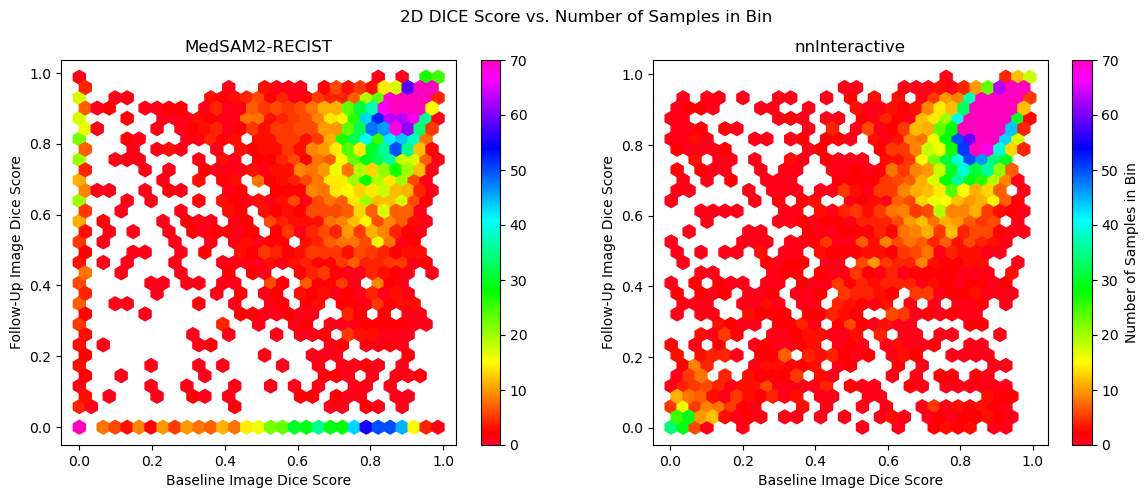

In [10]:
count_2d_fig, count_2d_axes = plt.subplots(figsize = (14,5), nrows = 1, ncols = 2)

count_2d_gridsize = 30
count_2d_cmap = 'gist_rainbow'
count_2d_vmin = 0
count_2d_vmax = 70

# For MedSAM2-RECIST 
ms2r_count = count_2d_axes[0].hexbin(ms2r_recist_df['t1_2D_DICE'], ms2r_recist_df['t2_2D_DICE'],
                               gridsize = count_2d_gridsize,
                               cmap = count_2d_cmap,
                               mincnt = 1,
                               vmin = count_2d_vmin,
                               vmax = count_2d_vmax,
                               )
count_2d_axes[0].set_title("MedSAM2-RECIST")
count_2d_axes[0].set_xlabel("Baseline Image Dice Score") 
count_2d_axes[0].set_ylabel("Follow-Up Image Dice Score")
cb = count_2d_fig.colorbar(ms2r_count, ax = count_2d_axes[0])

# For nnInteractive
nnint_count = count_2d_axes[1].hexbin(nnint_recist_df['t1_2D_DICE'], nnint_recist_df['t2_2D_DICE'],
                                gridsize = count_2d_gridsize,
                                cmap = count_2d_cmap,
                                mincnt = 1,
                                vmin = count_2d_vmin,
                                vmax = count_2d_vmax,
                            )
count_2d_axes[1].set_title("nnInteractive")
count_2d_axes[1].set_xlabel("Baseline Image Dice Score") 
count_2d_axes[1].set_ylabel("Follow-Up Image Dice Score")
cb = count_2d_fig.colorbar(nnint_count, ax = count_2d_axes[1])

cb.set_label("Number of Samples in Bin") 

count_2d_fig.suptitle("2D DICE Score vs. Number of Samples in Bin")

Text(0.5, 0.98, '2D DICE Score vs. RECIST Flip Proportion \n (alpha max = 70) \n')

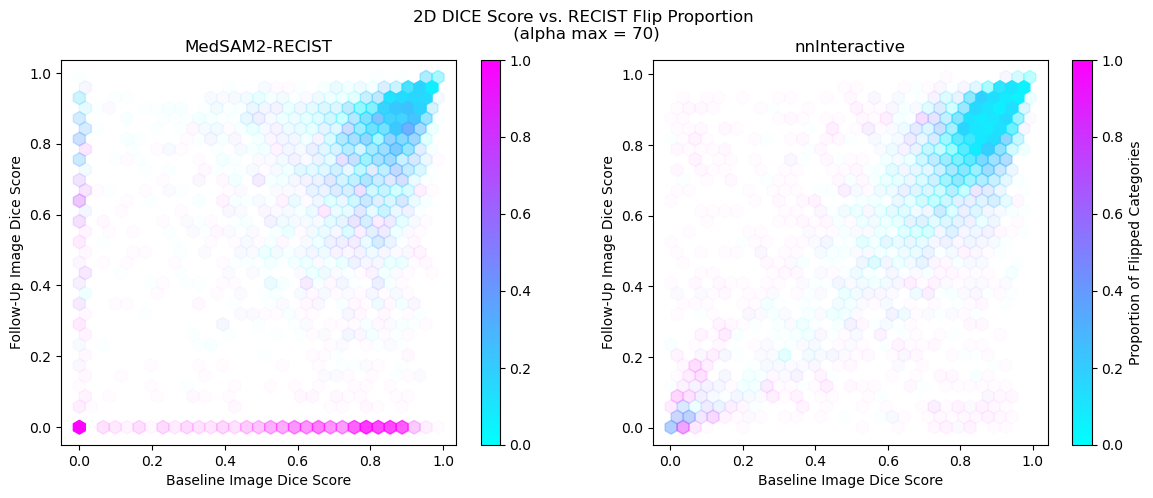

In [ ]:
alpha_2d_flip_fig, alpha_2d_flip_axes = plt.subplots(figsize = (14,5), nrows = 1, ncols = 2)
# For MedSAM2-RECIST 
ms2r_hb = alpha_2d_flip_axes[0].hexbin(ms2r_recist_df['t1_2D_DICE'], ms2r_recist_df['t2_2D_DICE'], C=ms2r_recist_df['RECIST_flip'], 
                         reduce_C_function=np.mean, gridsize = 30, cmap = 'cool')

alpha_2d_flip_axes[0].figure.canvas.draw()

fcolors = ms2r_hb.get_facecolors()
scaled_2d_ms2r_count = np.minimum(ms2r_count.get_array() / count_2d_vmax, 1)
fcolors[:, 3] = scaled_2d_ms2r_count
ms2r_hb.set(array=None, facecolor=fcolors)

alpha_2d_flip_axes[0].set_title("MedSAM2-RECIST")
alpha_2d_flip_axes[0].set_xlabel("Baseline Image Dice Score") 
alpha_2d_flip_axes[0].set_ylabel("Follow-Up Image Dice Score")
cb = alpha_2d_flip_fig.colorbar(ms2r_hb, ax = alpha_2d_flip_axes[0])

# For nnInteractive
nnint_hb = alpha_2d_flip_axes[1].hexbin(nnint_recist_df['t1_2D_DICE'], nnint_recist_df['t2_2D_DICE'], C=nnint_recist_df['RECIST_flip'], 
                         reduce_C_function=np.mean, gridsize=30, cmap='cool')

alpha_2d_flip_axes[1].figure.canvas.draw()

fcolors = nnint_hb.get_facecolors()
scaled_nnint_count = np.minimum(nnint_count.get_array() / count_vmax, 1)
fcolors[:, 3] = scaled_nnint_count
nnint_hb.set(array=None, facecolor=fcolors)

alpha_2d_flip_axes[1].set_title("nnInteractive")
alpha_2d_flip_axes[1].set_xlabel("Baseline Image Dice Score") 
alpha_2d_flip_axes[1].set_ylabel("Follow-Up Image Dice Score")
cb = alpha_2d_flip_fig.colorbar(nnint_hb, ax = alpha_2d_flip_axes[1])
cb.set_label("Proportion of Flipped Categories") 

alpha_2d_flip_fig.suptitle(f"2D DICE Score vs. RECIST Flip Proportion \n (alpha max = {count_2d_vmax})")


In [ ]:

alpha_2d_flip_fig.savefig()